### `4.) Loss Given Default (LGD) Modelling`

Loss Given Default (LGD) represents the proportion of a loan that is lost when a borrower defaults.

It is defined as:

LGD = 1 − Recovery Rate

Where recovery rate is the portion of the loan recovered after default through collections or other recovery processes.

In this stage we estimate LGD using loans that were charged off and analyze the distribution of loss severity across borrower segments.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("lendingclub_features.parquet")

df.shape

(1345310, 77)

### Filtering Defaulted Loans

LGD is defined only for loans that defaulted.

Therefore we restrict the dataset to loans where the borrower failed to repay and the loan was charged off.

In [2]:
df_default = df[df["default"] == 1].copy()

df_default.shape

(268559, 77)

### Calculating Recovery Rate

The dataset includes a variable called `recoveries`, which represents the amount recovered after the borrower defaulted.

We compute recovery rate as:

Recovery Rate = Recoveries / Loan Amount

In [6]:
df_default["recovery_rate"] = df_default["recoveries"] / df_default["loan_amnt"]

### Calculating Loss Given Default (LGD)

Loss Given Default is defined as the proportion of the loan that is not recovered after default.

LGD = 1 − Recovery Rate

In [7]:
df_default["lgd"] = 1 - df_default["recovery_rate"]

Quick Check

In [5]:
df_default[["loan_amnt","recoveries","recovery_rate","lgd"]].head()

,loan_amnt,recoveries,recovery_rate,lgd
10,18000.0,1618.90,0.089939,0.910061
21,4225.0,368.37,0.087188,0.912812
26,16000.0,0.00,0.000000,1.000000
27,24250.0,0.00,0.000000,1.000000
29,25000.0,0.00,0.000000,1.000000


Interpretation:

When no money is recovered, LGD = 1 (100% loss)

When some money is recovered, LGD < 1

This is exactly how LGD works in credit risk modelling.

### LGD Distribution

Before modelling LGD, we examine its distribution across defaulted loans.

In retail lending portfolios, LGD is often highly skewed because many defaulted loans result in little or no recovery.

Understanding the distribution of LGD helps identify typical loss severity patterns within the portfolio.

LGD Summary

In [9]:
df_default["lgd"].describe()

count    268559.000000
mean          0.924654
std           0.094909
min          -1.170300
25%           0.887500
50%           0.937885
75%           1.000000
max           1.000000
Name: lgd, dtype: float64

minimum LGD = -1.17

###### But LGD should theoretically be between 0 and 1.

###### This happens because sometimes recoveries > loan amount

###### This occasionally happens due to late fees, collection penalties, accounting adjustments.

###### But for LGD modelling we cap LGD between 0 and 1.

Fix LGD Values

###### In theory, Loss Given Default should lie between 0 and 1. In theory, Loss Given Default should lie between 0 and 1.

In [10]:
df_default["lgd"] = df_default["lgd"].clip(0,1)
df_default["lgd"].describe()

count    268559.000000
mean          0.924681
std           0.094601
min           0.000000
25%           0.887500
50%           0.937885
75%           1.000000
max           1.000000
Name: lgd, dtype: float64

LGD Histogram

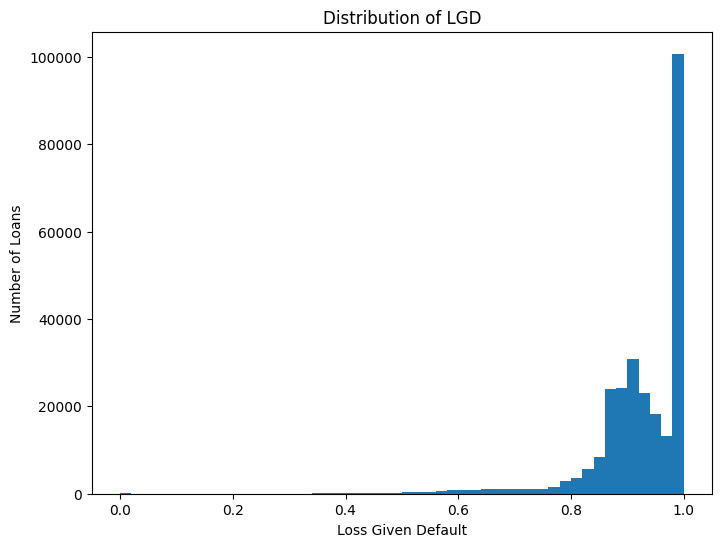

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(df_default["lgd"], bins=50)

plt.xlabel("Loss Given Default")
plt.ylabel("Number of Loans")
plt.title("Distribution of LGD")

plt.show()

#### LGD Distribution Insights

The LGD distribution is heavily concentrated near 1, indicating that many defaulted loans result in minimal recoveries.

This pattern is common in unsecured consumer lending, where lenders often recover only a small portion of the outstanding loan after default.

#### PREPARE DATASET FOR LGD MODELLING

We will prepare Features for LGD Model. We now remove columns that leak information.

To estimate LGD, we use borrower and loan characteristics that were available at loan origination.

Variables that directly contain recovery information are excluded to avoid data leakage.

In [12]:
X_lgd = df_default.drop(["lgd","recovery_rate","recoveries","default","issue_d"], axis=1)

y_lgd = df_default["lgd"]

#### Handling Infinite Values

Some engineered ratio features may produce infinite values when the denominator is extremely small or zero.

These infinite values are replaced with missing values and then imputed using the median to ensure numerical stability during model training.

In [13]:
import numpy as np

X_lgd = X_lgd.replace([np.inf, -np.inf], np.nan)

X_lgd = X_lgd.fillna(X_lgd.median())

#### TRAIN / TEST SPLIT of DATASET

In [14]:
from sklearn.model_selection import train_test_split

X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, y_lgd, test_size=0.2, random_state=42
)

### Train LGD Model (Random Forest)

We use a Random Forest regression model to estimate Loss Given Default.

Random Forest models can capture nonlinear relationships between borrower characteristics and recovery outcomes.

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_lgd = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_lgd.fit(X_train_lgd, y_train_lgd)

lgd_pred = rf_lgd.predict(X_test_lgd)

Save LGD Model for use in Expected Loss Notebook

In [13]:
import joblib

joblib.dump(rf_lgd, "rf_lgd_model.pkl")

['rf_lgd_model.pkl']

##### EVALUATE LGD MODEL

In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_lgd, lgd_pred))

print("LGD RMSE:", rmse)

LGD RMSE: 0.09444177049889474


LGD Root Mean Square Error values hover usually around 0.10 – 0.20. LGD prediction is usually noisy, so anything around 0.10 is strong.

##### Fix Predicted LGD Values

Loss Given Default theoretically lies between 0 and 1.

Since regression models can occasionally produce predictions slightly outside this range, predicted LGD values are capped between 0 and 1 to ensure realistic loss estimates.

In [18]:
lgd_pred = np.clip(lgd_pred, 0, 1)

##### Scatter Plot: Predicted vs Actual LGD

This is the standard regression diagnostic plot.

If the model performs well, predicted values should align reasonably close to the diagonal line representing perfect predictions.

Because LGD outcomes are highly variable in consumer lending portfolios, some dispersion around the diagonal is expected.

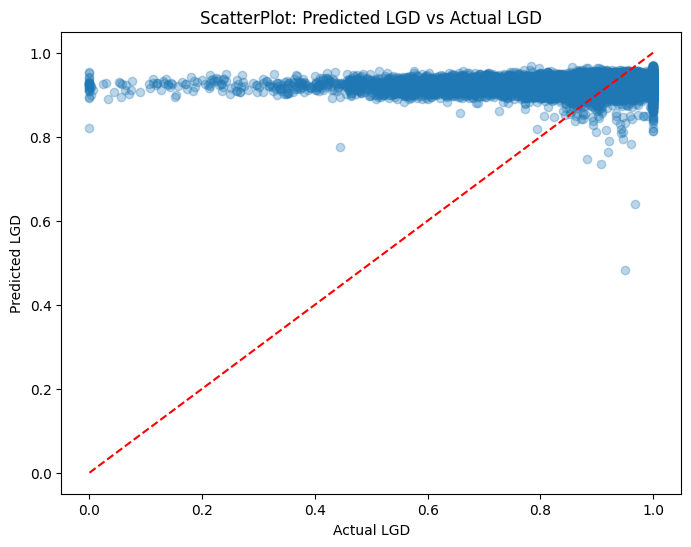

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test_lgd, lgd_pred, alpha=0.3)

plt.plot([0,1], [0,1], color='red', linestyle='--')

plt.xlabel("Actual LGD")
plt.ylabel("Predicted LGD")
plt.title("ScatterPlot: Predicted LGD vs Actual LGD")

plt.show()

Heavy clustering near LGD ≈ 1 → most defaulted loans had very low recoveries. This is reaistic for `unsecured consumer lending.`

The spread below the diagonal shows some underprediction for extreme losses, which is common because LGD is highly noisy.

The pattern we see is typical when most loans result in near-total loss after default.